--- Part A: Linear vs Cubic Polyfit ---
Linear (Deg 1) -> MSE: 3.7887, R-Squared: 0.0068
Cubic  (Deg 3) -> MSE: 3.6361, R-Squared: 0.0468
Evaluation: The Cubic Polynomial is a 'better' mathematical fit to the training data.


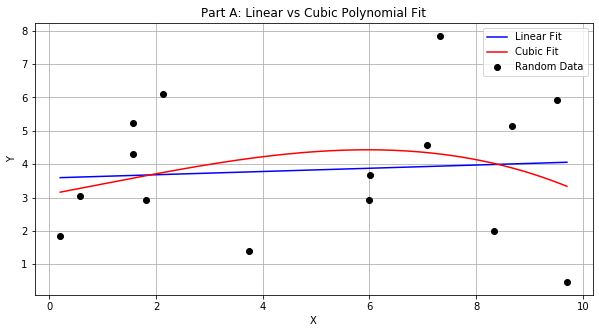


--- Part B: Iterating Polynomial Degrees ---
Degree  1 -> MSE:  3.7887, R-Squared:  0.0068
Degree  2 -> MSE:  3.6432, R-Squared:  0.0449
Degree  3 -> MSE:  3.6361, R-Squared:  0.0468
Degree  4 -> MSE:  2.6919, R-Squared:  0.2943
Degree  5 -> MSE:  2.5306, R-Squared:  0.3366
Degree  6 -> MSE:  2.5016, R-Squared:  0.3442
Degree  7 -> MSE:  2.2474, R-Squared:  0.4108
Degree  8 -> MSE:  1.0392, R-Squared:  0.7276
Degree  9 -> MSE:  0.9746, R-Squared:  0.7445
Degree 10 -> MSE:  0.9664, R-Squared:  0.7466
Degree 11 -> MSE:  0.9472, R-Squared:  0.7517
Degree 12 -> MSE:  0.0818, R-Squared:  0.9786


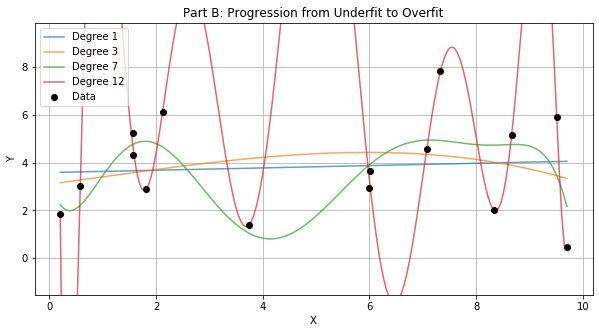


--- Part C: Cubic Fit via Vandermonde Matrix ---
Manual Vandermonde Cubic -> MSE: 3.6361, R-Squared: 0.0468
(For reference, Numpy's Cubic MSE was: 3.6361)
Success: The manual Vandermonde method matches the built-in polyfit!


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Helper Functions for Metrics
# ==========================================
def calculate_metrics(y_true, y_pred):
    """Calculates Mean Squared Error (MSE) and R-Squared (R2)."""
    mse = np.mean((y_true - y_pred)**2)
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    return mse, r2

# Generate a single set of random data for all parts (sorted X)
np.random.seed(42) # Seeded for consistent results across runs
X = np.sort(np.random.rand(15) * 10)
Y = np.random.rand(15) * 10

# High-resolution X for smooth plotting of polynomials
X_plot = np.linspace(min(X), max(X), 200)

# ==========================================
# Part A: Linear Least Squares vs Cubic Polyfit
# ==========================================
print("--- Part A: Linear vs Cubic Polyfit ---")

# 1. Linear Least Squares (Degree 1)
coeffs_linear = np.polyfit(X, Y, 1)
Y_pred_linear = np.polyval(coeffs_linear, X)
mse_lin, r2_lin = calculate_metrics(Y, Y_pred_linear)

# 2. Cubic Polynomial (Degree 3)
coeffs_cubic = np.polyfit(X, Y, 3)
Y_pred_cubic = np.polyval(coeffs_cubic, X)
mse_cub, r2_cub = calculate_metrics(Y, Y_pred_cubic)

print(f"Linear (Deg 1) -> MSE: {mse_lin:.4f}, R-Squared: {r2_lin:.4f}")
print(f"Cubic  (Deg 3) -> MSE: {mse_cub:.4f}, R-Squared: {r2_cub:.4f}")

# Code evaluation for the better fit (based strictly on R-Squared)
if r2_cub > r2_lin:
    print("Evaluation: The Cubic Polynomial is a 'better' mathematical fit to the training data.")
else:
    print("Evaluation: The Linear model is a 'better' mathematical fit to the training data.")

# Plot Part A
plt.figure(figsize=(10, 5))
plt.scatter(X, Y, color='black', label='Random Data', zorder=5)
plt.plot(X_plot, np.polyval(coeffs_linear, X_plot), color='blue', label='Linear Fit')
plt.plot(X_plot, np.polyval(coeffs_cubic, X_plot), color='red', label='Cubic Fit')
plt.title("Part A: Linear vs Cubic Polynomial Fit")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# Part B: Cranking the Degree (Underfit to Overfit)
# ==========================================
print("\n--- Part B: Iterating Polynomial Degrees ---")
# We test degrees from 1 (underfit) up to 12 (blatant overfit)
degrees_to_test = range(1, 13)

plt.figure(figsize=(10, 5))
plt.scatter(X, Y, color='black', label='Data', zorder=5)

for d in degrees_to_test:
    # Fit the polynomial
    coeffs = np.polyfit(X, Y, d)
    Y_pred = np.polyval(coeffs, X)
    
    # Evaluate
    mse, r2 = calculate_metrics(Y, Y_pred)
    print(f"Degree {d:2} -> MSE: {mse:7.4f}, R-Squared: {r2:7.4f}")
    
    # Plot a few specific degrees to avoid a cluttered graph
    if d in [1, 3, 7, 12]:
        plt.plot(X_plot, np.polyval(coeffs, X_plot), alpha=0.7, label=f'Degree {d}')

plt.title("Part B: Progression from Underfit to Overfit")
plt.xlabel("X")
plt.ylabel("Y")
plt.ylim([min(Y)-2, max(Y)+2]) # Constrain Y limits to see the severe overfit curves
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# Part C: The Vandermonde Matrix
# ==========================================
print("\n--- Part C: Cubic Fit via Vandermonde Matrix ---")

# Let's recreate the degree 3 (cubic) fit manually
degree = 3

# 1. Build the Vandermonde Matrix manually (columns: x^0, x^1, x^2, x^3)
# Note: np.vander(X, N) usually outputs x^(N-1) down to x^0. 
# We set increasing=True to match standard math notation (x^0 to x^N).
V = np.vander(X, N=degree+1, increasing=True)

# 2. Solve the Normal Equations: Beta = (V^T * V)^-1 * V^T * Y
V_T = V.T
V_T_V_inv = np.linalg.inv(V_T.dot(V))
beta_vandermonde = V_T_V_inv.dot(V_T).dot(Y)

# 3. Predict Y values using the solved Beta coefficients
# Beta contains [intercept, x_coeff, x2_coeff, x3_coeff]
Y_pred_vander = V.dot(beta_vandermonde)

# 4. Evaluate
mse_vander, r2_vander = calculate_metrics(Y, Y_pred_vander)

print(f"Manual Vandermonde Cubic -> MSE: {mse_vander:.4f}, R-Squared: {r2_vander:.4f}")

# Compare to Numpy's Polyfit from Part A
print(f"(For reference, Numpy's Cubic MSE was: {mse_cub:.4f})")
if np.isclose(mse_vander, mse_cub):
    print("Success: The manual Vandermonde method matches the built-in polyfit!")


--- Part B: Iterating Polynomial Degrees ---


NameError: name 'plt' is not defined